# Human-in-the-Loop (HITL) in LangGraph

**Human-in-the-Loop (HITL)** is a design pattern that allows an AI agent to pause its execution and request human approval, input, or intervention before continuing. This capability is essential for workflows involving sensitive operations, high-risk decisions, or tasks that require human judgment. LangGraph provides built-in support for HITL through **interrupts** and **checkpointers**, enabling developers to create safe, controllable, and production-ready AI agents.

## Why Human-in-the-Loop?

While LLMs are powerful, they should not always make autonomous decisions. HITL ensures that important actions are verified by a human before execution.

Common scenarios include:

- Sending emails
- Processing payments
- Approving financial transactions
- Executing database updates
- Deleting resources
- Deploying production code
- Accessing confidential information

## How Human-in-the-Loop Works

A LangGraph workflow can intentionally pause before executing a critical action. The current graph state is saved using a **checkpointer**, allowing the workflow to resume seamlessly after human approval.

```text
            User Request
                  │
                  ▼
          ┌────────────────┐
          │   Agent Graph  │
          └───────┬────────┘
                  │
                  ▼
          LLM Reasoning Node
                  │
                  ▼
      Critical Action Detected?
           │              │
          No             Yes
           │              │
           ▼              ▼
        Continue      Interrupt Graph
                           │
                           ▼
                  Human Review & Approval
                           │
                ┌──────────┴──────────┐
                ▼                     ▼
             Approve               Reject
                │                     │
                ▼                     ▼
       Resume Graph Execution    Modify/Cancel
                │
                ▼
          Continue Workflow
```

## Core Components

- **Interrupt:** Pauses graph execution at a specific point.
- **Checkpointer:** Saves the graph state so execution can resume later.
- **Human Reviewer:** Reviews, approves, rejects, or modifies the requested action.
- **Resume Execution:** Continues the workflow from the interruption point.

## Benefits

- Prevents unintended or harmful actions
- Adds human oversight to AI decisions
- Supports compliance and governance requirements
- Improves reliability for enterprise applications
- Enables collaborative human-AI workflows
- Allows workflows to resume without losing context

## Common Use Cases

- Email approval systems
- Financial transaction validation
- Customer support escalation
- Production deployment approvals
- Medical and legal decision support
- Document review workflows
- Multi-agent collaboration with human supervision

## Human-in-the-Loop in LangGraph

LangGraph implements HITL using the **`interrupt()`** function together with **checkpointing**. When an interrupt is triggered, the graph pauses, stores its current state, and waits for external input. Once a human provides approval or additional information, the graph resumes execution from the exact point where it stopped, preserving all previous context and state.

## Best Practices

- Use interrupts only for high-risk or irreversible actions.
- Always configure a persistent checkpointer (SQLite, PostgreSQL, or Redis) for production.
- Provide clear approval prompts for human reviewers.
- Log approval decisions for auditing and compliance.
- Resume execution using the same `thread_id` to preserve workflow state.

## Conclusion

Human-in-the-Loop is a critical capability for building trustworthy AI systems. By combining **interrupts**, **checkpointing**, and **human approval**, LangGraph enables developers to create AI agents that are not only intelligent but also safe, transparent, and reliable. This approach ensures that critical decisions remain under human control while allowing AI to automate the rest of the workflow efficiently.

In [16]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,
    max_retries=2,
    # other params...
)
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024CFDB8E990>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024CFDB8E350>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [17]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.types import Command,interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]
graph_builder = StateGraph(State)

@tool
def human_assistant(query:str)->str:
    """Request human assistance"""
    human_response = interrupt({"query": query})
    return human_response['data']
    
tool =TavilySearch(max_results=2)
tools = [tool, human_assistant]
llm_with_tool = model.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tool.invoke(state["messages"])
    return {"messages": [message]}


graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools)
graph_builder.add_node('tools', tool_node)
graph_builder.add_conditional_edges('chatbot', tools_condition)
graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge(START, 'chatbot')




In [18]:
memory = MemorySaver()

graph=graph_builder.compile(checkpointer=memory)


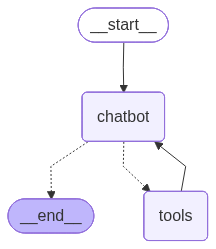

In [19]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred: {e}")

In [20]:
user_input = "I Need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "thread_4"}}
events = graph.stream(
    {"messages": [("user", user_input)]}, config=config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        if "messages" in event:
            print(event["messages"][-1].pretty_print())

================================ Human Message =================================

I Need some expert guidance for building an AI agent. Could you request assistance for me?
None
================================== Ai Message ==================================
Tool Calls:
  human_assistant (v1gpr6tjq)
 Call ID: v1gpr6tjq
  Args:
    query: I need expert guidance for building an AI agent.
None
================================== Ai Message ==================================
Tool Calls:
  human_assistant (v1gpr6tjq)
 Call ID: v1gpr6tjq
  Args:
    query: I need expert guidance for building an AI agent.
None


In [22]:
human_assistant = (
    "Hi! I'm currently building an AI agent and could really use some expert guidance on the architecture, best practices, and implementation. If possible, could you connect me with someone who has experience in this area? I'd really appreciate the help. Thanks!",
    "Hello! I'm working on building an AI agent and have reached a point where I'd benefit from some expert advice. I'm looking for guidance on designing scalable agent workflows, selecting the right architecture, integrating tools and memory, and following production best practices. If you could connect me with someone experienced in AI agents or agentic systems, I'd greatly appreciate it. Thank you!",
)
human_command = Command(resume={"data": human_assistant})
events = graph.stream(
    human_command, config=config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        if "messages" in event:
            print(event["messages"][-1].pretty_print())

================================== Ai Message ==================================
Tool Calls:
  human_assistant (6rr7mz12g)
 Call ID: 6rr7mz12g
  Args:
    query: I need expert guidance for building an AI agent.
None
================================= Tool Message =================================
Name: human_assistant

["Hi! I'm currently building an AI agent and could really use some expert guidance on the architecture, best practices, and implementation. If possible, could you connect me with someone who has experience in this area? I'd really appreciate the help. Thanks!", "Hello! I'm working on building an AI agent and have reached a point where I'd benefit from some expert advice. I'm looking for guidance on designing scalable agent workflows, selecting the right architecture, integrating tools and memory, and following production best practices. If you could connect me with someone experienced in AI agents or agentic systems, I'd greatly appreciate it. Thank you!"]
None
==========